# Basic functionality of `tnreason` explained on a propositional formula

The formula $$f = (X_0\lor X_1) \land (\lnot X_2)$$ is represented as a Computation-Activation Network based on the python package `tnreason`. The form of the network can be seen in form of a diagram in example 4.6 or in the section 7.

In [2]:
!pip install tnreason==2.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.2/587.2 kB 36.7 MB/s eta 0:00:00


In [3]:
from tnreason import engine, representation, application

The formula with a single binary output can be interppreted as one feature, for which the calculation is encoded by nested lists.

In [14]:
expressionsDict = {
    "f0" :  ["and", ["or", "X_0", "X_1"], ["not", "X_2"]]
}

All cores necessary to represent the formula can be created with suffices `_aC` for activation cores and `_cC` for computation cores.

In [15]:
cores = application.create_cores_to_expressionsDict(expressionsDict)
computationCores = {key: value for key, value in cores.items() if key.endswith("_cC")}

For further clarification we draw a factor grpah of the tensor network `cores`.


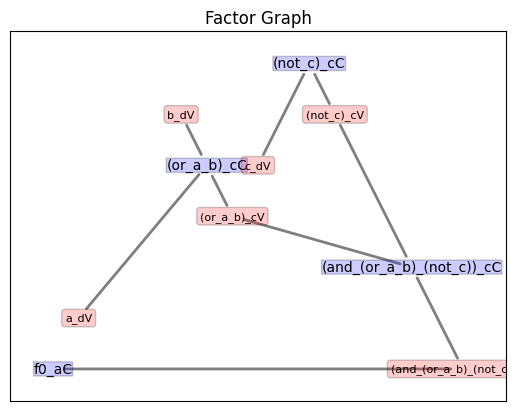

In [16]:
engine.draw_factor_graph(cores)

Then the computation-activation-network is created, where the computation cores are created as above. The activation cores are set to hybrid feature, which are allowed to be boolean as well as real valued. We are interested in the cases for, which the given feature formula is `True`, meaning we set the `"f0"` to `True` in the `canParamDict`.

In [6]:
caNet = representation.ComputationActivationNetwork(
    computationCoreDict=computationCores,
    featureDict={"f0" : representation.SingleHybridFeature(featureColor="(and_(or_X_0_X_1)_(not_X_2))_cV")},
    canParamDict={"f0" : True}
)
allCores = caNet.create_cores()

The resulting graph structure of the resulting CAN can be visualized.
Furthermore, the implementation can be checked by contractions. The network can be normalized to represent a uniform probability distribution over all models of the formula.

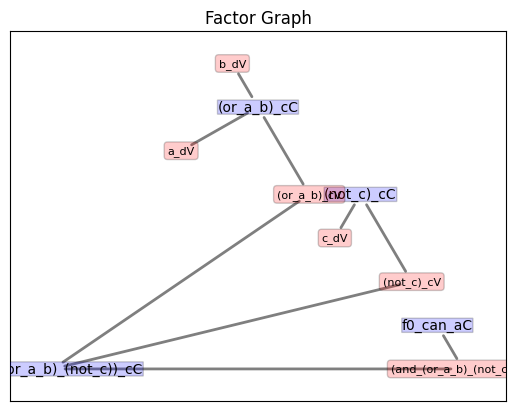

In [7]:
from tnreason import engine

engine.draw_factor_graph(allCores)
formula = engine.contract(coreDict = allCores, openColors=["X_0_dV","X_1_dV", "X_2_dV"])
assert formula[{"X_0_dV": 1, "X_1_dV" : 1, "X_2_dV" : 0}] == 1
assert formula[{"X_0_dV": 1, "X_1_dV" : 1, "X_2_dV" : 1}] == 0

distribution = engine.normalize(coreDict = allCores, outColors = ["X_0_dV","X_1_dV", "X_2_dV"], inColors = [])
assert distribution[{"X_0_dV": 1, "X_1_dV" : 1, "X_2_dV" : 0}] == 1/3
assert distribution[{"X_0_dV": 1, "X_1_dV" : 1, "X_2_dV" : 1}] == 0

# Simplification to two formulas

As described in section 4.4, the formula can also be seperated at the "and" and be understood as two subformulas as described in example 4.6, i.e. two features are assumed. One describes the "a or b" and the other one describes "c". The activation network then act on both these features. The same procedure as for the single feature can be repeated with multiple features.

In [8]:
expressionsDict2 = {
    "f0" :  ["or", "X_0", "X_1"],
    "f1" :  ["X_2"]
}
cores = application.create_cores_to_expressionsDict(expressionsDict2)
computationCores2 = {key: value for key, value in cores.items() if key.endswith("_cC")}

featureDict2 = {
    "f0" : representation.SingleHybridFeature(featureColor="(or_X_0_X_1)_cV"),
    "f1" : representation.SingleHybridFeature(featureColor="X_2_dV")
}

canParamDict2 = {
    "f0" : True,
    "f1" : False
}

In [9]:
caNet2 = representation.ComputationActivationNetwork(
    computationCoreDict=computationCores2,
    featureDict=featureDict2,
    canParamDict=canParamDict2
)
allCores2 = caNet2.create_cores()

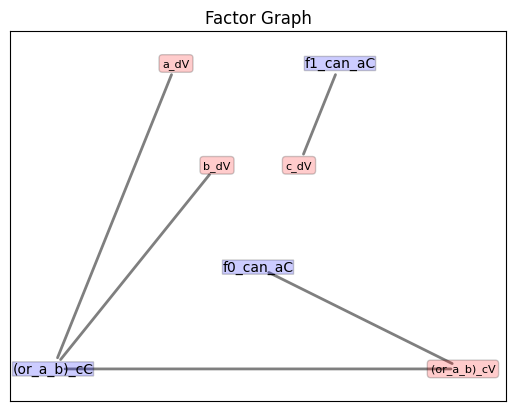

In [10]:
from tnreason import engine

engine.draw_factor_graph(allCores2)

formula = engine.contract(coreDict = allCores2, openColors=["X_0_dV","X_1_dV", "X_2_dV"])
assert formula[{"X_0_dV": 1, "X_1_dV" : 1, "X_2_dV" : 0}] == 1
assert formula[{"X_0_dV": 1, "X_1_dV" : 1, "X_2_dV" : 1}] == 0

distribution = engine.normalize(coreDict = allCores2, outColors = ["X_0_dV","X_1_dV", "X_2_dV"], inColors = [])
assert distribution[{"X_0_dV": 1, "X_1_dV" : 1, "X_2_dV" : 0}] == 1/3
assert distribution[{"X_0_dV": 1, "X_1_dV" : 1, "X_2_dV" : 1}] == 0

# Entailment check

In this section, we want to answer the question: If the CAN returns `True` at a given `(X_0,X_1,X_2)`, does `(X_0,X_1,X_2)` also fulfill `checkFormula`? This entailment is checked here for a part of the formula, for which we therefore know that the entailment is `True`.

In [1]:
from tnreason.application import formulas_to_cores as ftc

checkFormula = ["or","X_0","X_1"]
formulaVarColor = ftc.get_formula_string(checkFormula)+"_cV" # need suffix _dV if atomic variable

entailmentCANet = representation.ComputationActivationNetwork(
    computationCores = computationCores2,
    featureDict={**featureDict2,"check": representation.SingleHybridFeature(featureColor=formulaVarColor)},
    canParamDict={**canParamDict2,"check" : False}
)

print("Formula {} is entailed: {}".format(checkFormula, bool(not engine.contract(coreDict=entailmentCANet.create_cores(), openColors=[])[:])))

contradictionCANet = representation.ComputationActivationNetwork(
    computationCores = computationCores2,
    featureDict={**featureDict2,"check": representation.SingleHybridFeature(featureColor=formulaVarColor)},
    canParamDict={**canParamDict2,"check" : True}
)
print("Formula {} is contradicted: {}".format(checkFormula, bool(not engine.contract(coreDict=contradictionCANet.create_cores(), openColors=[])[:])))

NameError: name 'representation' is not defined